In [66]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect()
con.execute('''
    CREATE TABLE prescribers AS
    SELECT * FROM read_csv_auto('medicare_prescribing/partd_prescribers/prescriber_data.csv')
''')

con.execute('''
    CREATE TABLE drugs AS
    SELECT * FROM read_csv_auto('medicare_prescribing/partd_prescribers_drugs/prescriber_drug_data.csv')
''')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [28]:
print(con.execute("DESCRIBE prescribers").df())

print("-----")

print(con.execute("DESCRIBE drugs").df())


              column_name column_type null   key default extra
0             PRSCRBR_NPI      BIGINT  YES  None    None  None
1   Prscrbr_Last_Org_Name     VARCHAR  YES  None    None  None
2      Prscrbr_First_Name     VARCHAR  YES  None    None  None
3              Prscrbr_MI     VARCHAR  YES  None    None  None
4         Prscrbr_Crdntls     VARCHAR  YES  None    None  None
..                    ...         ...  ...   ...     ...   ...
79   Bene_Race_Natind_Cnt      BIGINT  YES  None    None  None
80     Bene_Race_Othr_Cnt      BIGINT  YES  None    None  None
81          Bene_Dual_Cnt      BIGINT  YES  None    None  None
82         Bene_Ndual_Cnt      BIGINT  YES  None    None  None
83     Bene_Avg_Risk_Scre      DOUBLE  YES  None    None  None

[84 rows x 6 columns]
-----
              column_name column_type null   key default extra
0             Prscrbr_NPI      BIGINT  YES  None    None  None
1   Prscrbr_Last_Org_Name     VARCHAR  YES  None    None  None
2      Prscrbr_First_Name 

In [32]:
con.execute('''
    SELECT *
    FROM prescribers
    LIMIT 5
''').df()

,PRSCRBR_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_MI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_St1,Prscrbr_St2,Prscrbr_City,Prscrbr_State_Abrvtn,...,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Dual_Cnt,Bene_Ndual_Cnt,Bene_Avg_Risk_Scre
0,1003000126,Enkeshafi,Ardalan,None,M.D.,I,6410 Rockledge Dr Ste 304,None,Bethesda,MD,...,48,73,17,11,<NA>,0,<NA>,33,79,2.960628
1,1003000142,Khalil,Rashid,None,M.D.,I,4126 N Holland Sylvania Rd,Suite 220,Toledo,OH,...,167,226,212,<NA>,26,<NA>,13,300,178,1.996720
2,1003000167,Escobar,Julio,E,DDS,I,5 Pine Cone Rd,None,Dayton,NV,...,28,54,0,0,0,<NA>,<NA>,<NA>,<NA>,0.890862
3,1003000423,Velotta,Jennifer,A,M.D.,I,11100 Euclid Ave,None,Cleveland,OH,...,<NA>,59,<NA>,<NA>,<NA>,0,<NA>,<NA>,<NA>,0.844284
4,1003000480,Rothchild,Kevin,B,MD,I,12605 E 16th Ave,None,Aurora,CO,...,11,19,<NA>,0,<NA>,0,<NA>,<NA>,<NA>,1.664445


In [33]:
con.execute('''
    SELECT *
    FROM drugs
    LIMIT 5
''').df()

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
0,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Eliquis,Apixaban,...,437,8828.74,<NA>,#,<NA>,NaN,NaN,<NA>,*,<NA>
1,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Prednisone,Prednisone,...,153,54.98,14,#,<NA>,NaN,NaN,<NA>,#,<NA>
2,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,...,1020,491.38,12,#,<NA>,NaN,NaN,<NA>,*,<NA>
3,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,...,1050,471.01,15,#,<NA>,NaN,NaN,<NA>,*,<NA>
4,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Baclofen,Baclofen,...,1890,796.10,23,None,27,29.0,417.86,870,*,<NA>


In [112]:
top_drugs = con.execute("""
    SELECT Gnrc_Name, SUM(tot_drug_cst) AS total_cost
    FROM drugs
    GROUP BY Gnrc_Name
    ORDER BY total_cost DESC
    LIMIT 20
""").df()

top_drugs['total_cost_B'] = round((top_drugs['total_cost'].apply(lambda x: f"{x:.2f}").astype(float)/1000000000),2).astype(str) + "B"
top_drugs.head()

,Gnrc_Name,total_cost,total_cost_B
0,Apixaban,1.739216e+10,17.39B
1,Semaglutide,9.670619e+09,9.67B
2,Empagliflozin,8.031744e+09,8.03B
3,Dulaglutide,6.666365e+09,6.67B
4,Rivaroxaban,5.511694e+09,5.51B


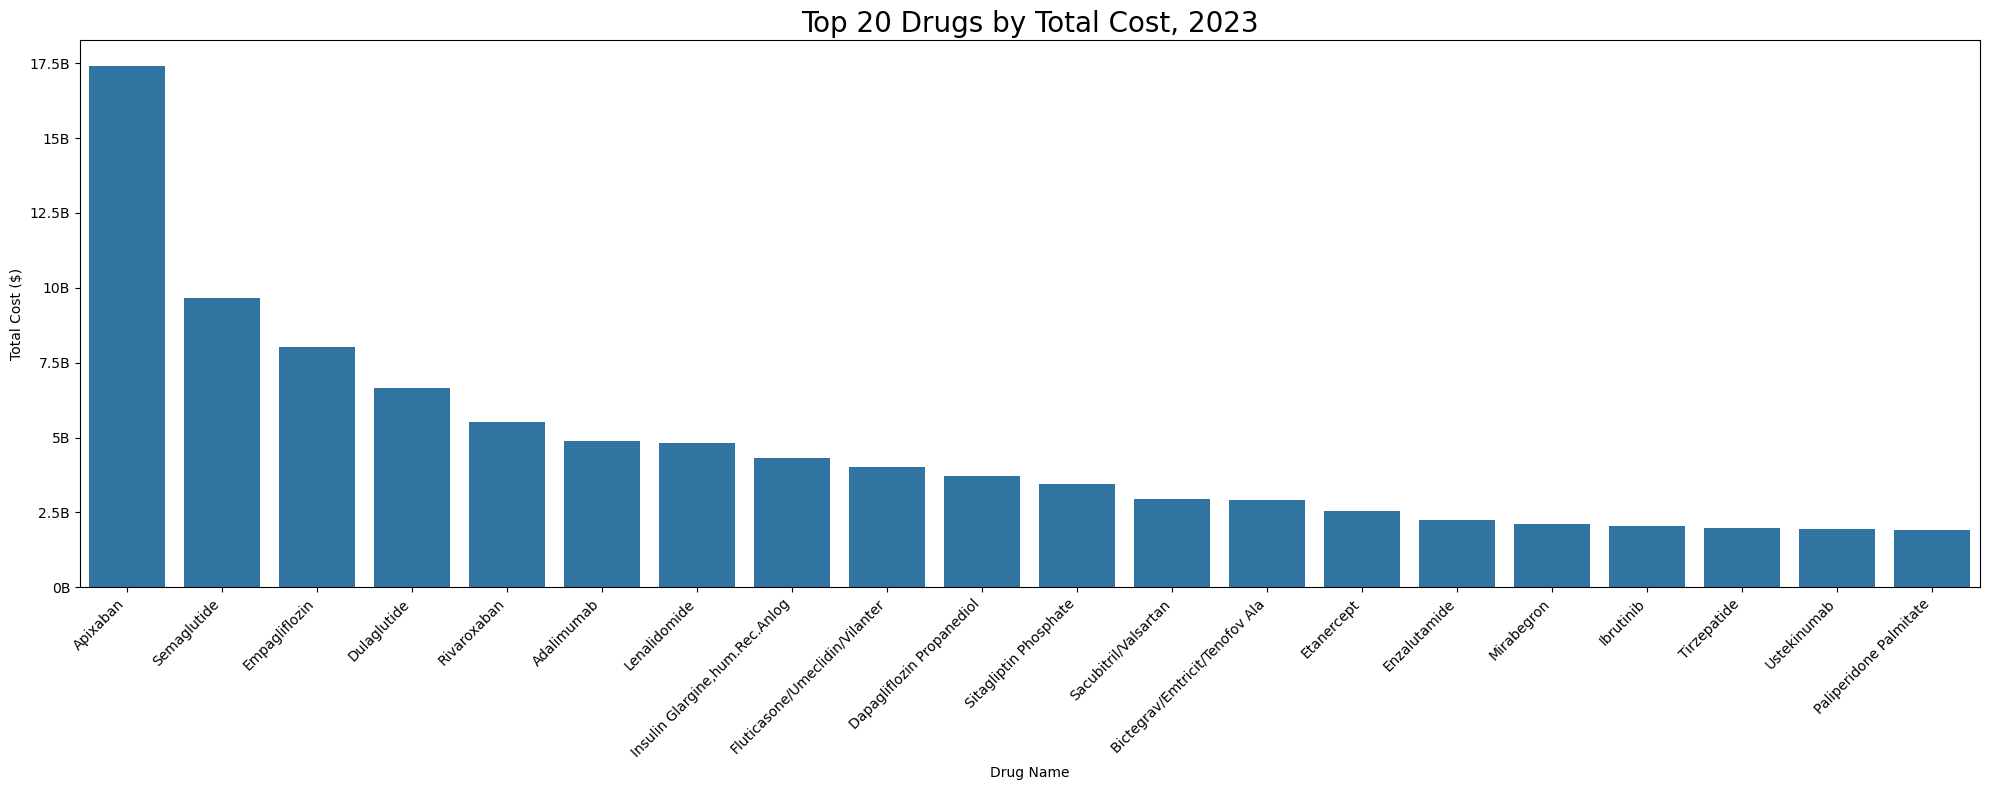

In [111]:
import matplotlib.ticker as ticker
plt.figure(figsize = (20, 8))
plt.xticks(rotation = 45, ha = 'right')
ax = sns.barplot(data = top_drugs,
                 x = 'Gnrc_Name',
                 y = 'total_cost')
def billions(x, pos):
    return f'{x/1e9:g}B'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(billions))
ax.set_xlabel('Drug Name')
ax.set_ylabel('Total Cost ($)')
ax.set_title('Top 20 Drugs by Total Cost, 2023', fontsize = 20)
plt.tight_layout() 
plt.show()

In [114]:
state_count = con.execute('''
    SELECT Prscrbr_State_Abrvtn AS State,
        COUNT(1) AS Count
    FROM prescribers
    GROUP BY Prscrbr_State_Abrvtn
    ORDER BY Count DESC;
''').df()

state_count.head(10)

,State,Count
0,CA,139057
1,NY,104092
2,FL,93928
3,TX,92813
4,PA,64171
5,OH,53444
6,IL,53002
7,MI,46434
8,NC,44019
9,MA,39945


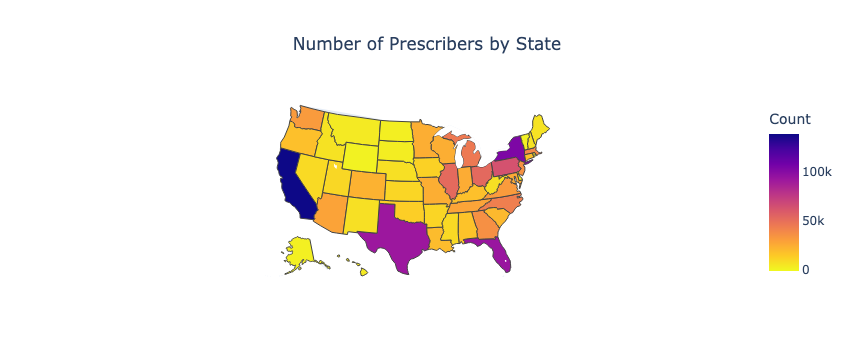

In [123]:
import plotly.express as px

fig = px.choropleth(state_count,
                    locations = 'State',
                    locationmode = 'USA-states',
                    color = 'Count',
                    color_continuous_scale = 'Plasma_r',
                    scope = 'usa',
                    title = 'Number of Prescribers by State'
                   )
fig.update_layout(title_x = 0.5)
fig.show()

In [125]:
con.execute('''
    CREATE TABLE state_pops AS
    SELECT * FROM 'data/NST-EST2023-ALLDATA.csv'
''')

In [202]:
state_pops = con.execute('''
    SELECT NAME,POPESTIMATE2023
    FROM state_pops
    WHERE STATE != 00;
''').df()

# dictionary of state abbreviations and the full name
abbreviation_to_name = {
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#States.
    "AK": "Alaska","AL": "Alabama","AR": "Arkansas", "AZ": "Arizona", "CA": "California", "CO": "Colorado","CT": "Connecticut",
    "DE": "Delaware","FL": "Florida","GA": "Georgia","HI": "Hawaii","IA": "Iowa","ID": "Idaho","IL": "Illinois","IN": "Indiana",
    "KS": "Kansas","KY": "Kentucky","LA": "Louisiana","MA": "Massachusetts","MD": "Maryland","ME": "Maine","MI": "Michigan",
    "MN": "Minnesota","MO": "Missouri","MS": "Mississippi","MT": "Montana","NC": "North Carolina","ND": "North Dakota",
    "NE": "Nebraska", "NH": "New Hampshire","NJ": "New Jersey","NM": "New Mexico","NV": "Nevada","NY": "New York","OH": "Ohio",
    "OK": "Oklahoma","OR": "Oregon","PA": "Pennsylvania","RI": "Rhode Island","SC": "South Carolina","SD": "South Dakota",
    "TN": "Tennessee", "TX": "Texas","UT": "Utah","VA": "Virginia","VT": "Vermont","WA": "Washington","WI": "Wisconsin",
    "WV": "West Virginia","WY": "Wyoming",
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#Federal_district.
    "DC": "District of Columbia",
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#Inhabited_territories.
    "AS": "American Samoa","GU": "Guam GU","MP": "Northern Mariana Islands","PR": "Puerto Rico","VI": "U.S. Virgin Islands",
}

# create new dictionary with full state names as the keys
keys = {v:k for k,v in abbreviation_to_name.items()}

# change state names from full to abbreviated for state population 
state_pops['NAME'] = [keys[state] for state in state_pops['NAME']]
#
non_states = list(list(specialties['State'].unique()) - abbreviation_to_name.keys())

state_count = pd.merge(state_count, state_pops, left_on = 'State', right_on = 'NAME', how = 'left')

In [154]:
state_count['Count_per_100k'] = 100000 * state_count['Count'] / state_count['POPESTIMATE2023']

In [160]:
state_count.sort_values(by = 'Count_per_100k', ascending = False).head()

,State,Count,NAME,POPESTIMATE2023,Count_per_cap,Count_per_100k
43,DC,5191,DC,678972.0,0.007645,764.538155
9,MA,39945,MA,7001399.0,0.005705,570.528833
24,CT,19551,CT,3617176.0,0.005405,540.504526
1,NY,104092,NY,19571216.0,0.005319,531.862711
42,RI,5750,RI,1095962.0,0.005247,524.653227


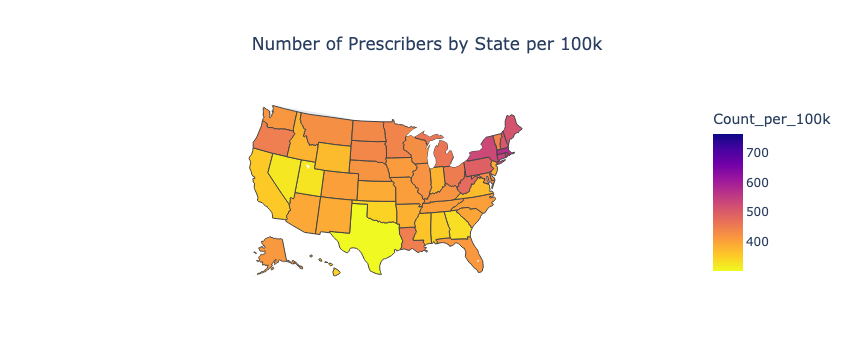

In [161]:
fig = px.choropleth(state_count,
                    locations = 'State',
                    locationmode = 'USA-states',
                    color = 'Count_per_100k',
                    color_continuous_scale = 'Plasma_r',
                    scope = 'usa',
                    title = 'Number of Prescribers by State per 100k'
                   )
fig.update_layout(title_x = 0.5)
fig.show()

In [220]:
specialties = con.execute('''
    SELECT Prscrbr_State_Abrvtn AS State,
        Prscrbr_Type AS Specialty,
        COUNT(1) As Count
    FROM prescribers
    WHERE Prscrbr_Type != 'Nurse Practitioner'
    GROUP BY State, Specialty;
''').df()

# remove 
specialties = specialties[~specialties['State'].isin(non_states)]
specialties.sort_values(by = 'Count', ascending = False)


,State,Specialty,Count
4587,CA,Dentist,16755
1279,CA,Internal Medicine,15825
1282,CA,Family Practice,13471
4604,NY,Physician Assistant,12282
3232,NY,Student in an Organized Health Care Education/...,11797
...,...,...,...
1916,TX,General Acute Care Hospital,1
1915,ND,Diagnostic Radiology,1
1914,ID,Oral & Maxillofacial Surgery,1
1913,OR,Nurse's Aide,1


In [309]:
specialty_variance = (specialties
    .groupby('Specialty')['Count']
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)

specialty_variance.sort_values('std', ascending=False).head(20)

,Specialty,mean,std,min,max
84,Internal Medicine,2289.196429,2979.517303,1,15825
41,Dentist,2386.290909,2951.620143,1,16755
149,Physician Assistant,2352.890909,2682.555813,2,12282
57,Family Practice,2117.909091,2379.521818,6,13471
187,Student in an Organized Health Care Education/...,1257.754717,1931.851393,2,11797
53,Emergency Medicine,1010.851852,1172.898834,6,5995
141,Pharmacist,656.581818,972.138568,1,5761
121,Obstetrics & Gynecology,622.218182,718.507808,1,3713
125,Optometry,603.309091,617.756631,2,3144
159,Psychiatry,442.592593,564.062539,1,2978


In [222]:
print('The amount of times a state has only 1 provider for a particular specialty:',len(specialties[specialties['Count'] == 1]))
print('The amount of times a state has 5 or fewer providers for a particular specialty:',len(specialties[specialties['Count'] <= 5]))

The amount of times a state has only 1 provider for a particular specialty: 779
The amount of times a state has 5 or fewer providers for a particular specialty: 1598


In [251]:
# states with the highest number of occurrences of specialties with only one provider
specialties[specialties['Count'] == 1].groupby(by = 'State').sum()['Count'].sort_values(ascending = False).reset_index().head(10)

,State,Count
0,CA,26
1,FL,26
2,AZ,22
3,OH,21
4,WY,20
5,OK,20
6,OR,20
7,NC,20
8,PR,20
9,MA,20


In [250]:
state_totals = specialties.groupby('State')['Count'].sum().reset_index()
state_totals.columns = ['State', 'state_total']

specialty_totals = specialties.groupby('Specialty')['Count'].sum().reset_index()
specialty_totals.columns = ['Specialty', 'specialty_total']

total = specialties['Count'].sum()

specialties_enriched = (specialties
    .merge(state_totals, on = 'State', how = 'left')
    .merge(specialty_totals, on = 'Specialty', how = 'left')
)

specialties_enriched['expected'] = (
    specialties_enriched['state_total'] * 
    specialties_enriched['specialty_total'] / total
)

specialties_enriched['location_quotient'] = (
    specialties_enriched['Count'] / 
    specialties_enriched['expected']
)

specialties_enriched.head()

,State,Specialty,Count,state_total,specialty_total,expected,location_quotient
0,NY,Internal Medicine,10915,88533,128195,10119.656233,1.078594
1,MO,Internal Medicine,2373,19692,128195,2250.869964,1.054259
2,UT,Otolaryngology,118,9040,10640,85.762918,1.375886
3,NY,Family Practice,4907,88533,116485,9195.274046,0.533644
4,IL,Family Practice,4702,43853,116485,4554.689807,1.032343


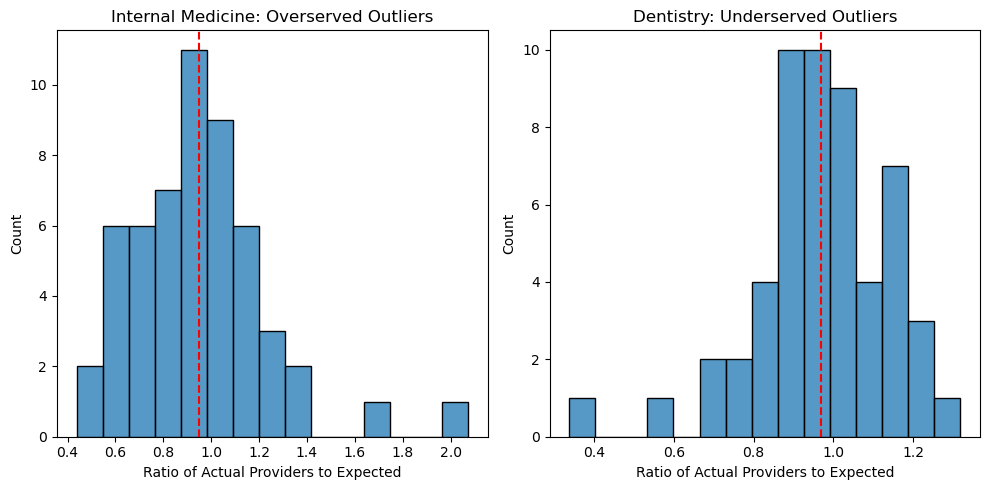

In [313]:
# underserved states based on expected number of practitioners by state
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

IM = specialties_enriched[(specialties_enriched['expected'] > 5) & (specialties_enriched['Specialty'] == 'Internal Medicine')].sort_values(by = 'location_quotient',ascending = True)
IM_plot = sns.histplot(IM,
             x = 'location_quotient', 
             bins = 15,
             ax = axes[0])
IM_plot.axvline(IM['location_quotient'].mean(), color = 'red',linestyle = 'dashed')
IM_plot.set_title('Internal Medicine: Overserved Outliers')
IM_plot.set_xlabel('Ratio of Actual Providers to Expected')


dentists = specialties_enriched[(specialties_enriched['expected'] > 5) & (specialties_enriched['Specialty'] == 'Dentist')].sort_values(by = 'location_quotient',ascending = True)
dent_plot = sns.histplot(dentists,
             x = 'location_quotient',
             bins = 15,
             ax = axes[1])
dent_plot.axvline(dentists['location_quotient'].mean(), color = 'red',linestyle = 'dashed')
dent_plot.set_title('Dentistry: Underserved Outliers')
dent_plot.set_xlabel('Ratio of Actual Providers to Expected')

plt.tight_layout()


In [308]:
IM_iqr = IM['location_quotient'].quantile(.75) - IM['location_quotient'].quantile(.25)
IM_lower = IM['location_quotient'].quantile(.25) - 1.5 * IM_iqr
IM_upper = IM['location_quotient'].quantile(.75) + 1.5 * IM_iqr
print(IM_lower,IM_upper)

print(IM[(IM['location_quotient'] > IM_upper) | (IM['location_quotient'] < IM_lower)][['State','location_quotient']])

dent_iqr = dentists['location_quotient'].quantile(.75) - dentists['location_quotient'].quantile(.25)
dent_lower = dentists['location_quotient'].quantile(.25) - 1.5 * dent_iqr
dent_upper = dentists['location_quotient'].quantile(.75) + 1.5 * dent_iqr
print(dent_lower,dent_upper)

print(dentists[(dentists['location_quotient'] > dent_upper) | (dentists['location_quotient'] < dent_lower)][['State','location_quotient']])


0.2680445510866586 1.5601194097018132
     State  location_quotient
1295    RI           1.679587
2849    GU           2.072041
0.5808344217689138 1.3678986572673186
     State  location_quotient
3712    GU           0.337312


In [367]:
underserved_dict = {}

for specialty in list(specialties_enriched['Specialty'].unique()):
    under_array = specialties_enriched[specialties_enriched['Specialty'] == specialty]['location_quotient']
    iqr = under_array.quantile(.75) - under_array.quantile(.25)
    lower = under_array.quantile(.25) - 1.5 * iqr
    underserved_state_list = list(specialties_enriched[(specialties_enriched['Specialty'] == specialty) & (specialties_enriched['location_quotient'] < lower)]['State'])
    if underserved_state_list: underserved_dict[specialty] = underserved_state_list
    else: pass
for key in underserved_dict:
    print(f"{key}: {underserved_dict[key]}")
    

Family Practice: ['DC', 'CT', 'PR']
Dentist: ['GU', 'MP']
Emergency Medicine: ['PR']
Optometry: ['PR']
Physician Assistant: ['PR']
Urology: ['NM']
Ophthalmology: ['WY']
Plastic and Reconstructive Surgery: ['PR', 'WY']
Pulmonary Disease: ['AK', 'WY']
Radiation Oncology: ['PR']
Endocrinology: ['WY']
Allergy/ Immunology: ['ME', 'WY']
Hematology-Oncology: ['ID']
Hand Surgery: ['WV']
Hospitalist: ['PR']
Surgical Oncology: ['ID']
Phlebology: ['FL']


In [368]:
underserved_dict.values()

dict_values([['DC', 'CT', 'PR'], ['GU', 'MP'], ['PR'], ['PR'], ['PR'], ['NM'], ['WY'], ['PR', 'WY'], ['AK', 'WY'], ['PR'], ['WY'], ['ME', 'WY'], ['ID'], ['WV'], ['PR'], ['ID'], ['FL']])

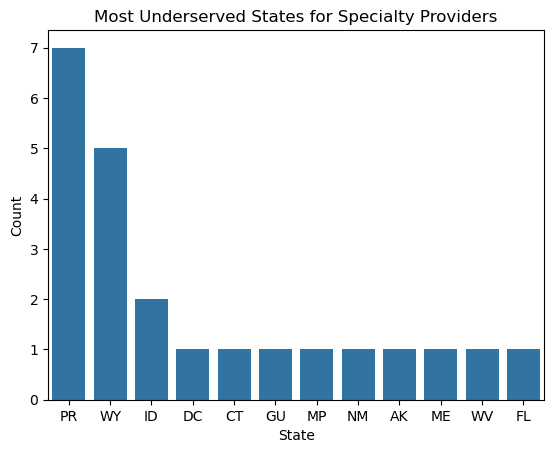

In [399]:
underserved_states_list = [item for sublist in underserved_dict.values() for item in sublist]

from collections import Counter

updated_under_dict = Counter(underserved_states_list)
undercounted_df = pd.DataFrame.from_dict(updated_under_dict, orient = 'index').reset_index()
undercounted_df.columns = ['State','Count']
undercounted_df.sort_values(by = 'Count', ascending = False)

sns.barplot(data = undercounted_df,
            x = 'State',
            y = 'Count',
            order = undercounted_df.sort_values(by = 'Count', ascending = False)['State'])
plt.title('Most Underserved States for Specialty Providers')
plt.show()
            

Counter({'PR': 7,
         'WY': 5,
         'ID': 2,
         'DC': 1,
         'CT': 1,
         'GU': 1,
         'MP': 1,
         'NM': 1,
         'AK': 1,
         'ME': 1,
         'WV': 1,
         'FL': 1})